In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv(r"/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [5]:
df.shape

(17966, 9)

In [6]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [7]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [8]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [9]:
print(df['engineSize'].unique())

[1.  1.5 1.6 1.2 2.  1.1 2.3 1.4 5.  2.2 2.5 1.8 1.3 3.2 0.  1.7]


<Axes: xlabel='price', ylabel='Count'>

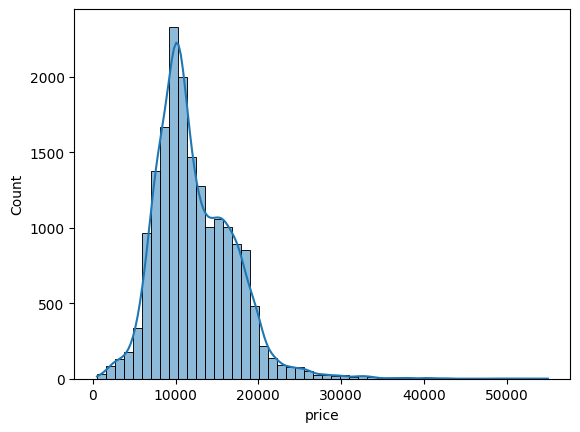

In [10]:
sns.histplot(df['price'],bins=50,kde=True)

In [11]:
df['price'].describe()

count    17966.000000
mean     12279.534844
std       4741.343657
min        495.000000
25%       8999.000000
50%      11291.000000
75%      15299.000000
max      54995.000000
Name: price, dtype: float64

In [12]:
q1=df['price'].quantile(0.25)
q3=df['price'].quantile(0.75)
IQR=q3-q1
lower_bound=q1-1.5*IQR
upper_bound=q1+1.5*IQR
df_cleaned=df.copy()
df_cleaned=df[(df['price']>=lower_bound) & (df['price']<=upper_bound)]
print("original shape:",df.shape)
print("after removing outliers:",df_cleaned.shape)

original shape: (17966, 9)
after removing outliers: (16189, 9)


<Axes: xlabel='price', ylabel='Count'>

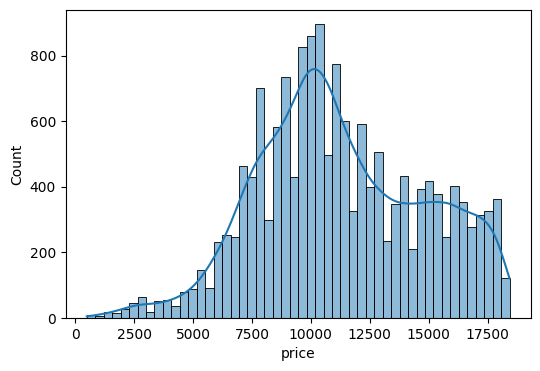

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['price'],bins=50,kde=True)

<Axes: >

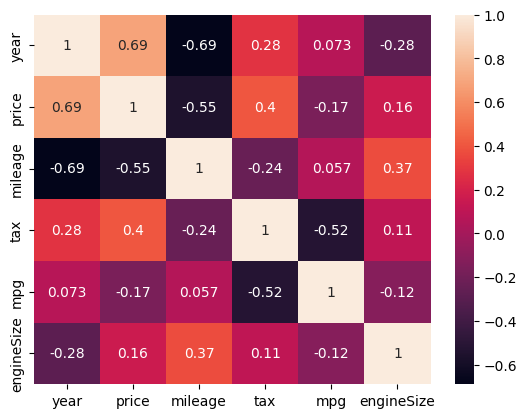

In [14]:
sns.heatmap(df_cleaned.corr(numeric_only=True),annot=True)

In [15]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

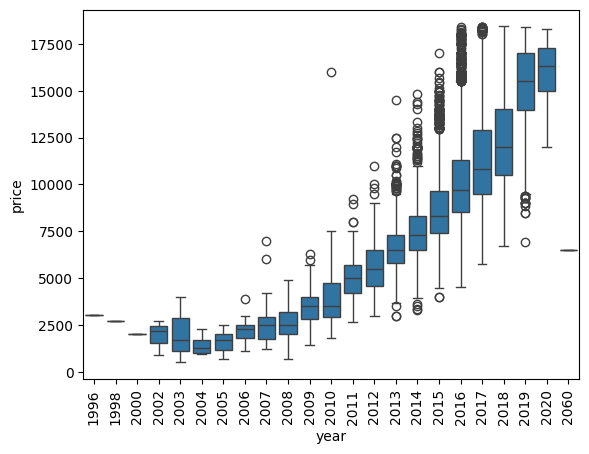

In [16]:
sns.boxplot(data=df_cleaned,x='year',y='price')
plt.xticks(rotation=90)

<Axes: xlabel='transmission', ylabel='price'>

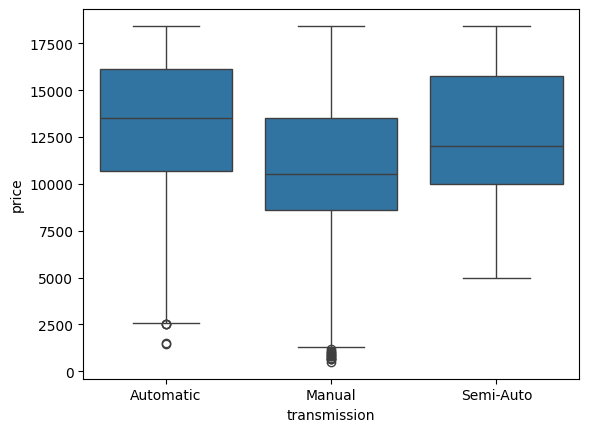

In [17]:
sns.boxplot(data=df_cleaned,x='transmission',y='price')

<Axes: xlabel='mileage', ylabel='price'>

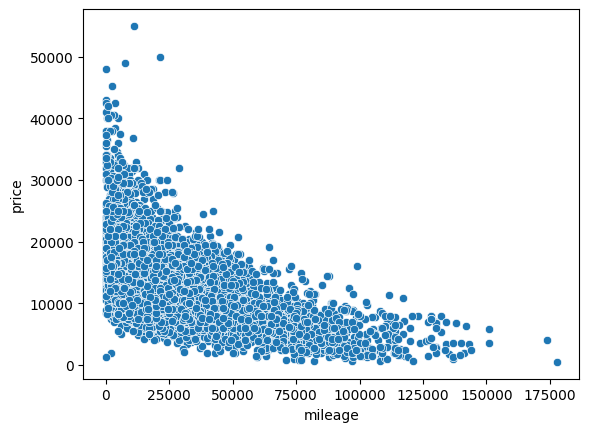

In [18]:
sns.scatterplot(data=df,x='mileage',y='price')

In [19]:
df['price'].describe()

count    17966.000000
mean     12279.534844
std       4741.343657
min        495.000000
25%       8999.000000
50%      11291.000000
75%      15299.000000
max      54995.000000
Name: price, dtype: float64

In [20]:
df['mileage'].describe()

count     17966.000000
mean      23362.608761
std       19472.054349
min           1.000000
25%        9987.000000
50%       18242.500000
75%       31060.000000
max      177644.000000
Name: mileage, dtype: float64

In [21]:
numerical_cols=['price','mileage']
for col in numerical_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q1+1.5*IQR
    df_cleaned=df.copy()
    df_cleaned=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
    print("original shape:",df.shape)
    print("after removing outliers:",df_cleaned.shape)

original shape: (17966, 9)
after removing outliers: (16189, 9)
original shape: (17966, 9)
after removing outliers: (15473, 9)


<Axes: xlabel='mileage', ylabel='price'>

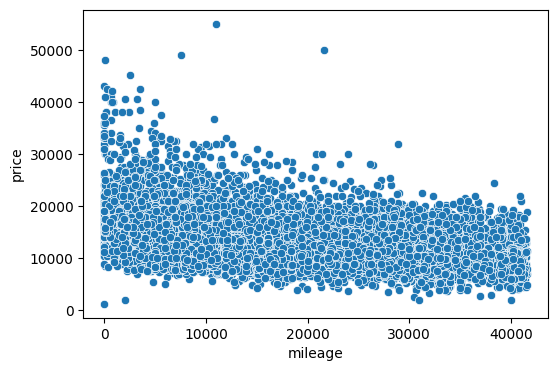

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_cleaned,x='mileage',y='price')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Transit Tourneo'),
  Text(20, 0, 'Focus')])

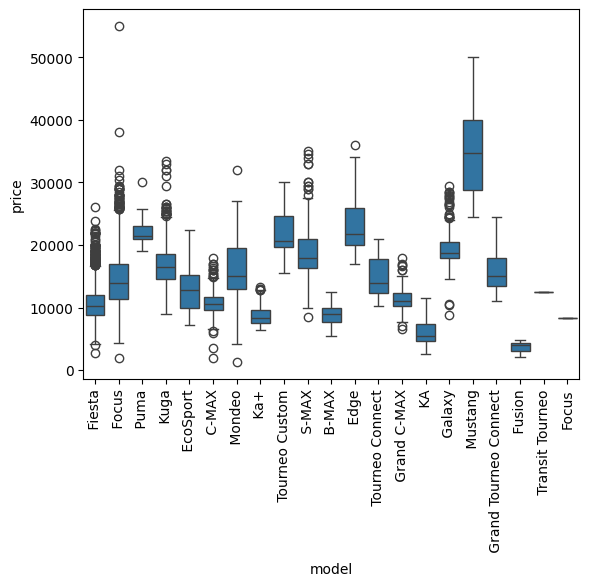

In [23]:
sns.boxplot(x=df_cleaned['model'],y=df_cleaned['price'])
plt.xticks(rotation=90)

In [24]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [25]:
x=df_cleaned.drop(columns=['price'],axis=1)
y=df_cleaned['price']
x

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [26]:
x_one_encoded=pd.get_dummies(x,columns=['model','transmission','fuelType'],drop_first=True,dtype=int)
x_one_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Fiesta,model_ Focus,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67.3,1.6,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57.7,1.2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [27]:
from sklearn.preprocessing import StandardScaler
numerical_cols=['year','mileage','tax','mpg','engineSize']
scaler=StandardScaler()
x_one_encoded[numerical_cols]=scaler.fit_transform(x_one_encoded[numerical_cols])
x_one_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Fiesta,model_ Focus,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,-0.212613,-0.123785,0.559414,0.003315,-0.740349,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,0.466669,-0.775626,0.559414,0.003315,-0.740349,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
2,-0.212613,-0.455169,0.559414,0.003315,-0.740349,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
3,1.145951,-0.644802,0.471545,-1.749567,0.413431,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
4,1.145951,-1.497773,0.471545,-0.903348,-0.740349,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,-0.212613,-0.051960,0.559414,-1.064533,0.182675,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-2.250459,2.228201,-1.549432,0.003315,-0.740349,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-1.571177,-0.972575,-1.725169,0.970422,0.644187,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
17964,0.466669,-1.162874,0.471545,0.003315,-0.278837,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [28]:
from sklearn.preprocessing import LabelEncoder
columns=['model','transmission','fuelType']
xlabel=x.copy()
label_encoders={}
for col in columns:
    le=LabelEncoder()
    xlabel[col]=le.fit_transform(xlabel[col].astype(str))
    label_encoders[col]=le
xlabel['model'].value_counts()

model
4     5892
5     3848
12    1908
2     1092
11     526
1      440
13     282
0      276
16     233
8      204
7      185
3      184
10     129
15      78
18      60
14      56
9       49
17      26
6        3
19       1
20       1
Name: count, dtype: int64

In [29]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [30]:
from sklearn.preprocessing import StandardScaler
numerical_cols=(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'])
scaler=StandardScaler()
xlabel[numerical_cols]=scaler.fit_transform(xlabel[numerical_cols])
xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.495661,-0.212613,-2.622690,-0.123785,0.629398,0.559414,0.003315,-0.740349
1,-0.225222,0.466669,0.039923,-0.775626,0.629398,0.559414,0.003315,-0.740349
2,-0.225222,-0.212613,0.039923,-0.455169,0.629398,0.559414,0.003315,-0.740349
3,-0.495661,1.145951,0.039923,-0.644802,0.629398,0.471545,-1.749567,0.413431
4,-0.495661,1.145951,-2.622690,-1.497773,0.629398,0.471545,-0.903348,-0.740349
...,...,...,...,...,...,...,...,...
17961,-1.577413,-0.212613,0.039923,-0.051960,0.629398,0.559414,-1.064533,0.182675
17962,-1.577413,-2.250459,0.039923,2.228201,0.629398,-1.549432,0.003315,-0.740349
17963,-0.225222,-1.571177,0.039923,-0.972575,-1.591129,-1.725169,0.970422,0.644187
17964,1.126968,0.466669,0.039923,-1.162874,0.629398,0.471545,0.003315,-0.278837


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
x_train,x_test,y_train,y_test=train_test_split(x_one_encoded,y,test_size=0.33,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
print("adjusted r2 score:",adjusted_r2)

adjusted r2 score: 0.8578681603137974


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
x_train,x_test,y_train,y_test=train_test_split(xlabel,y,test_size=0.33,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
print("adjusted r2 score:",adjusted_r2)

adjusted r2 score: 0.7229496468564404


In [34]:
import joblib
joblib.dump(model,'LinearRegression_FordCar.pkl')
joblib.dump(scaler,'Scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')
joblib.dump(le,'label_encoder.pkl')
joblib.dump(x_one_encoded,'one_hot_encoder.pkl')



import os
print(os.listdir())

['LinearRegression_FordCar.pkl', 'label_encoder.pkl', 'one_hot_encoder.pkl', '.virtual_documents', 'Scaler.pkl', 'columns.pkl']
